In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [158]:
# Data ingestion
data = yf.download('MSFT', start='2000-01-01', end='2026-03-03')['Close']
data= data.asfreq('B') #bussines day frequency
data = data.ffill() #interpolate missing values

[*********************100%***********************]  1 of 1 completed


In [171]:
data

Ticker,MSFT
Date,
2000-01-03,35.520370
2000-01-04,34.320496
2000-01-05,34.682365
2000-01-06,33.520569
2000-01-07,33.958630
...,...
2026-02-24,389.000000
2026-02-25,400.600006
2026-02-26,401.720001


In [89]:
#stationarity check
adf=adfuller(data)[1]
print(f'ADF p-value: {adf:.3f}')

ADF p-value: 0.992


In [55]:
first_value=data['MSFT'].iloc[0]

In [117]:
data=data.diff()

In [118]:
data=data.dropna()

In [119]:
#stationarity check
adf=adfuller(data)[1]
print(f'ADF p-value: {adf:.3f}')

ADF p-value: 0.000


In [183]:
#auto arima for best params
arima_model = auto_arima(data, seasonal=False, stepwise=True, suppress_warnings=True)
print(f'Best ARIMA: {arima_model.order}')

Best ARIMA: (5, 2, 0)


In [161]:
sarima_model = auto_arima(data, seasonal=True, m=5, stepwise=True, suppress_warnings=True)
print(f'Best SARIMA: {sarima_model.order}, Seasonal:{sarima_model.seasonal_order}')

Best SARIMA: (4, 2, 0), Seasonal:(2, 0, 0, 5)


In [177]:
# Train-test split
train, test = data[:5460], data[5460:]

In [178]:
train.shape

(5460, 1)

In [179]:
test.shape

(1366, 1)

In [116]:
train_o, test_o = data[:-60], data[-60:]

In [95]:
last_train_value = train[-1:]

In [184]:
#fit ARIMA
model_arima = SARIMAX(train, order=arima_model.order).fit(disp=False)
pred_arima = model_arima.get_forecast(steps=len(test)).predicted_mean

In [185]:
#fit SARIMA
model_sarima = SARIMAX(train, order=sarima_model.order,
                      seasonal_order=sarima_model.seasonal_order).fit(disp=False)
pred_sarima = model_sarima.get_forecast(steps=len(test)).predicted_mean

In [186]:
# metrics
for name, pred in [('ARIMA', pred_arima), ('SARIMA', pred_sarima)]:
    rmse = np.sqrt(mean_squared_error(test, pred))
    mae = mean_absolute_error(test, pred)
    print(f'{name} RMSE: {rmse:.2f}, MAE: {mae:.2f}')

ARIMA RMSE: 347.41, MAE: 298.39
SARIMA RMSE: 175.63, MAE: 147.64


In [165]:
# metrics
for name, pred in [('ARIMA', pred_arima), ('SARIMA', pred_sarima)]:
    rmse = np.sqrt(mean_squared_error(test, pred))
    mae = mean_absolute_error(test, pred)
    print(f'{name} RMSE: {rmse:.2f}, MAE: {mae:.2f}')

ARIMA RMSE: 107.83, MAE: 87.79
SARIMA RMSE: 75.33, MAE: 58.94


In [155]:
# Undo differencing
preda =pd.Series(pred_arima)
preds =pd.Series(pred_sarima)

pred_arima2= first_value + np.cumsum(preda)
pred_sarima2= first_value  + np.cumsum(preds)

In [156]:
pred_sarima2

2025-12-09    33.612085
2025-12-10    33.313997
2025-12-11    33.686617
2025-12-12    34.076014
2025-12-15    34.812204
2025-12-16    35.144564
2025-12-17    36.392958
2025-12-18    37.349552
2025-12-19    38.810637
2025-12-22    38.901328
2025-12-23    39.487828
2025-12-24    38.814457
2025-12-25    39.908077
2025-12-26    40.813731
2025-12-29    42.168103
2025-12-30    42.403147
2025-12-31    43.003497
2026-01-01    43.735978
2026-01-02    44.408911
2026-01-05    45.031373
2026-01-06    45.582389
2026-01-07    46.317143
2026-01-08    47.064748
2026-01-09    47.821658
2026-01-12    48.405862
2026-01-13    49.019657
2026-01-14    49.563393
2026-01-15    50.295804
2026-01-16    50.984478
2026-01-19    51.701008
2026-01-20    52.302013
2026-01-21    52.972115
2026-01-22    53.654428
2026-01-23    54.317493
2026-01-26    54.964816
2026-01-27    55.608480
2026-01-28    56.284935
2026-01-29    56.962187
2026-01-30    57.632714
2026-02-02    58.282018
2026-02-03    58.936082
2026-02-04    59

In [150]:
test= first_value + test.cumsum()

In [151]:
test

Ticker,MSFT
Date,
2025-12-09,72.038452
2025-12-10,95.127182
2025-12-11,123.114746
2025-12-12,146.173569
2025-12-15,165.530823
2025-12-16,186.454514
2025-12-17,207.108795
2025-12-18,235.605209
2025-12-19,266.037201


In [62]:
data

Ticker,MSFT
Date,
2000-01-04,34.320496
2000-01-05,34.682365
2000-01-06,33.520569
2000-01-07,33.958630
2000-01-10,34.206211
...,...
2026-02-24,389.000000
2026-02-25,400.600006
2026-02-26,401.720001


In [142]:
pred_arima2

,MSFT,2025-12-09 00:00:00,2025-12-10 00:00:00,2025-12-11 00:00:00,2025-12-12 00:00:00,2025-12-15 00:00:00,2025-12-16 00:00:00,2025-12-17 00:00:00,2025-12-18 00:00:00,2025-12-19 00:00:00,...,2026-02-17 00:00:00,2026-02-18 00:00:00,2026-02-19 00:00:00,2026-02-20 00:00:00,2026-02-23 00:00:00,2026-02-24 00:00:00,2026-02-25 00:00:00,2026-02-26 00:00:00,2026-02-27 00:00:00,2026-03-02 00:00:00
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
last_train_value

Ticker,MSFT
Date,
2025-12-08,489.901825


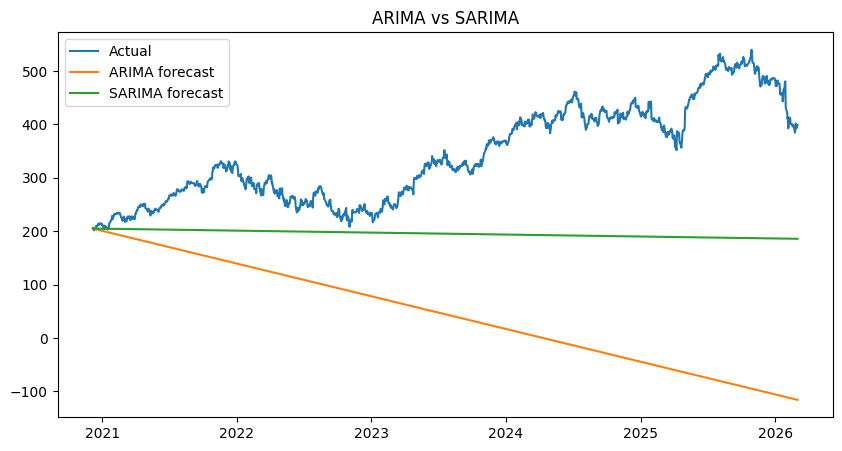

In [187]:
#plot results
plt.figure(figsize=(10,5))
#plt.plot(train, label='Train')
plt.plot(test, label='Actual')
#plt.plot(test, label='Actual 2')
plt.plot(pred_arima, label='ARIMA forecast')
plt.plot(pred_sarima, label='SARIMA forecast')
plt.legend()
plt.title('ARIMA vs SARIMA')
plt.show()